
# 📊 Exploratory Data Analysis (EDA)
## Balaji Fast Food Sales Dataset

---

### Objective:
To analyze sales performance, customer behavior, and time-based trends to derive meaningful business insights.

---

### Steps Covered:
- Data Understanding
- Data Cleaning Validation
- Feature Engineering
- Advanced Visualizations
- Business Insights


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)


## 📂 Load Dataset

In [2]:

df = pd.read_csv('balaji_fast_food_sales_dataset.csv')
df.head()


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,day_of_week,hour,customer_type,order_channel,preparation_time_minutes,item_popularity,profit_percent,Unnamed: 17
0,1,01-04-2024,Aalopuri,Fastfood,20.0,13,260.0,Card,Mr.,Night,Monday,00:54,New,Takeaway,19,Normal Demand,9,NaN
1,2,01-04-2024,Vadapav,Fastfood,20.0,15,300.0,Cash,Mr.,Afternoon,Monday,17:44,Returning,Dine-In,22,Normal Demand,78,NaN
2,3,01-04-2024,Vadapav,Fastfood,20.0,1,20.0,Cash,Mr.,Afternoon,Monday,05:12,Regular,Dine-In,16,Normal Demand,66,NaN
3,4,01-04-2024,Sugarcane juice,Beverages,25.0,6,150.0,Online,Mr.,Night,Thursday,17:59,Returning,Dine-In,13,High Demand,44,NaN
4,5,01-04-2024,Sugarcane juice,Beverages,25.0,8,200.0,Online,Mr.,Evening,Thursday,13:59,New,Dine-In,5,High Demand,44,NaN


## 🔍 Dataset Overview

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  20000 non-null  int64  
 1   date                      20000 non-null  object 
 2   item_name                 20000 non-null  object 
 3   item_type                 20000 non-null  object 
 4   item_price                20000 non-null  float64
 5   quantity                  20000 non-null  int64  
 6   transaction_amount        20000 non-null  float64
 7   transaction_type          20000 non-null  object 
 8   received_by               20000 non-null  object 
 9   time_of_sale              20000 non-null  object 
 10  day_of_week               20000 non-null  object 
 11  hour                      20000 non-null  object 
 12  customer_type             20000 non-null  object 
 13  order_channel             20000 non-null  object 
 14  prepar

,order_id,item_price,quantity,transaction_amount,preparation_time_minutes,profit_percent,Unnamed: 17
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,0.0
mean,10000.500000,33.063702,8.184400,273.316825,14.538500,50.147500,NaN
std,5773.647028,14.927312,4.457554,204.635623,5.773291,28.817419,NaN
min,1.000000,15.610000,1.000000,17.120000,5.000000,1.000000,NaN
25%,5000.750000,20.140000,4.000000,118.235000,10.000000,25.000000,NaN
50%,10000.500000,25.000000,8.000000,234.260000,15.000000,50.000000,NaN
75%,15000.250000,46.772500,12.000000,364.320000,20.000000,75.000000,NaN
max,20000.000000,72.450000,16.000000,1074.400000,24.000000,100.000000,NaN


## 🗓 Date Processing

In [4]:

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()


## 📈 Daily Sales Trend

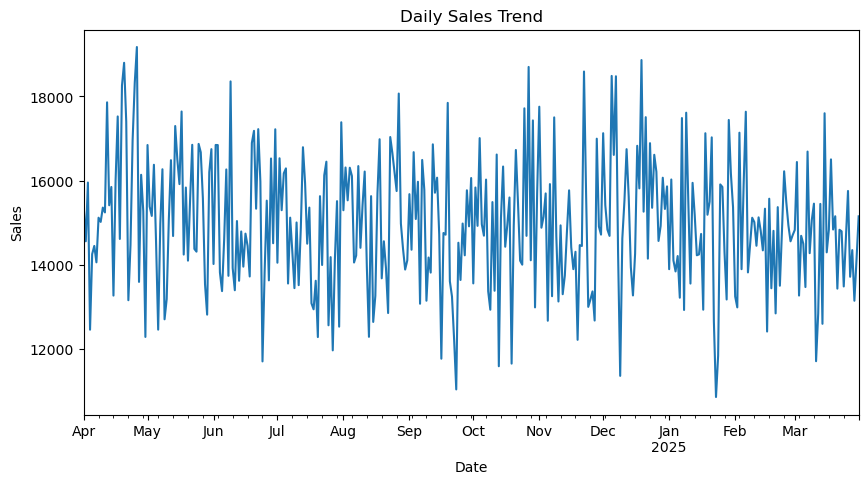

In [5]:

daily_sales = df.groupby('date')['transaction_amount'].sum()
daily_sales.plot(title='Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


## 📊 Monthly Sales Trend

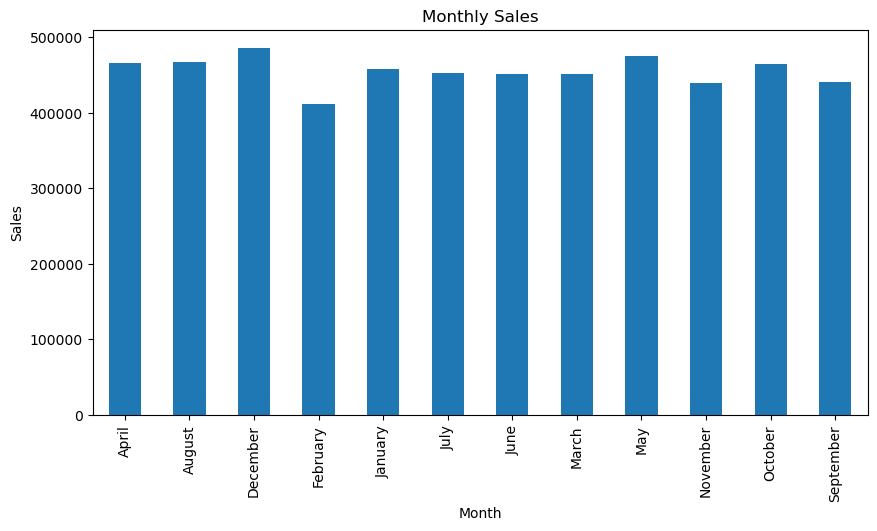

In [6]:

monthly_sales = df.groupby('month')['transaction_amount'].sum()
monthly_sales.plot(kind='bar', title='Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


## 🍔 Top Selling Items

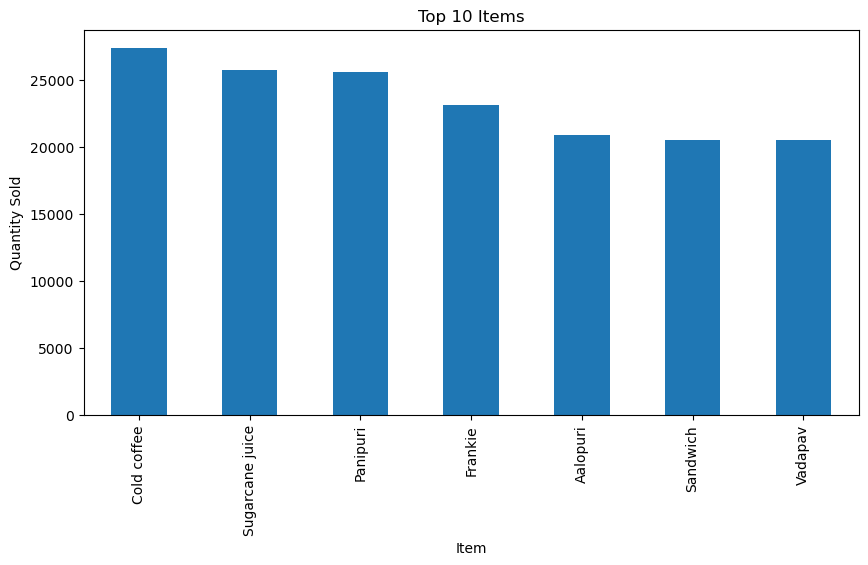

In [7]:

top_items = df.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(10)
top_items.plot(kind='bar', title='Top 10 Items')
plt.xlabel('Item')
plt.ylabel('Quantity Sold')
plt.show()


## ⏰ Sales by Hour

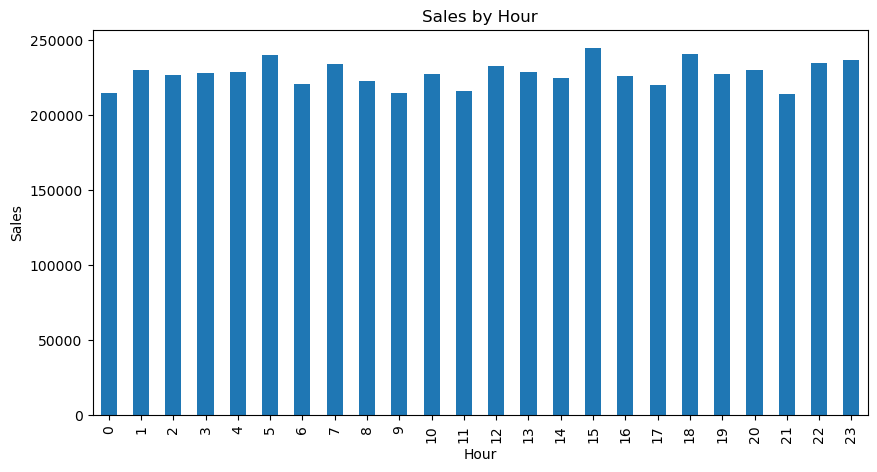

In [8]:

df['hour'] = df['hour'].astype(str).str[:2].astype(int)
hour_sales = df.groupby('hour')['transaction_amount'].sum()
hour_sales.plot(kind='bar', title='Sales by Hour')
plt.xlabel('Hour')
plt.ylabel('Sales')
plt.show()


## 📅 Sales by Day

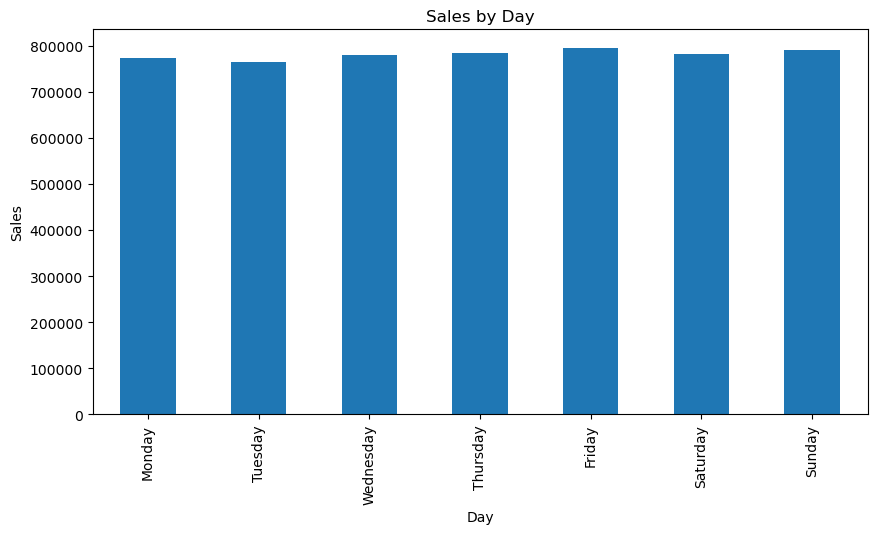

In [9]:

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('day')['transaction_amount'].sum().reindex(order)
day_sales.plot(kind='bar', title='Sales by Day')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()


## 🛒 Order Channel Distribution

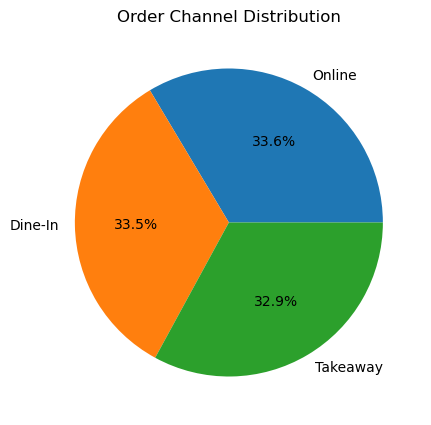

In [10]:

df['order_channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Order Channel Distribution')
plt.show()


## 👤 Customer Type Analysis

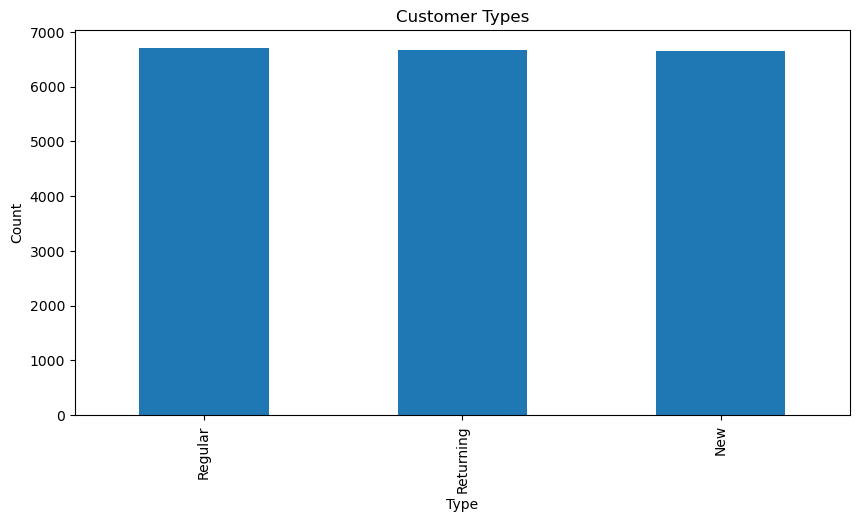

In [11]:

df['customer_type'].value_counts().plot(kind='bar', title='Customer Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


## 📊 Feature Correlation Analysis

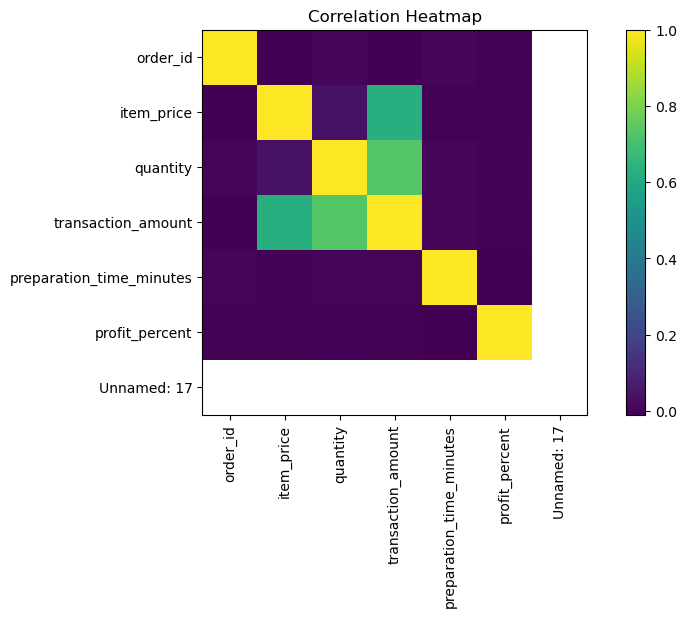

In [12]:

numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


## 💰 Price vs Quantity Relationship

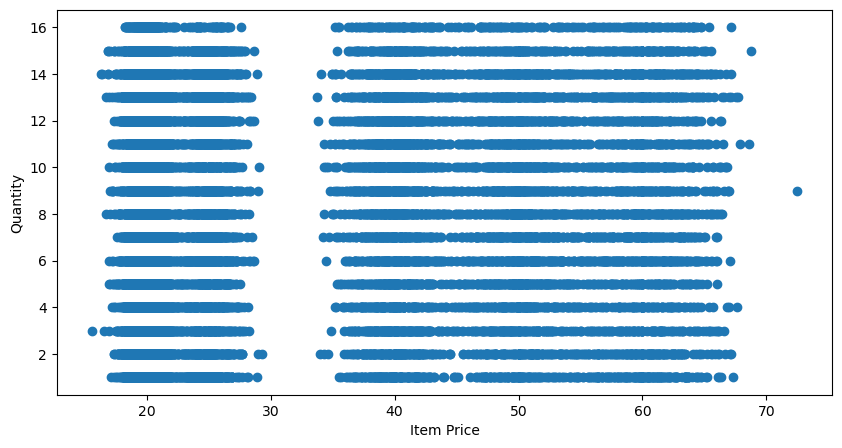

In [13]:

plt.scatter(df['item_price'], df['quantity'])
plt.xlabel("Item Price")
plt.ylabel("Quantity")
plt.show()


## 📈 Quantity vs Transaction Amount Trend

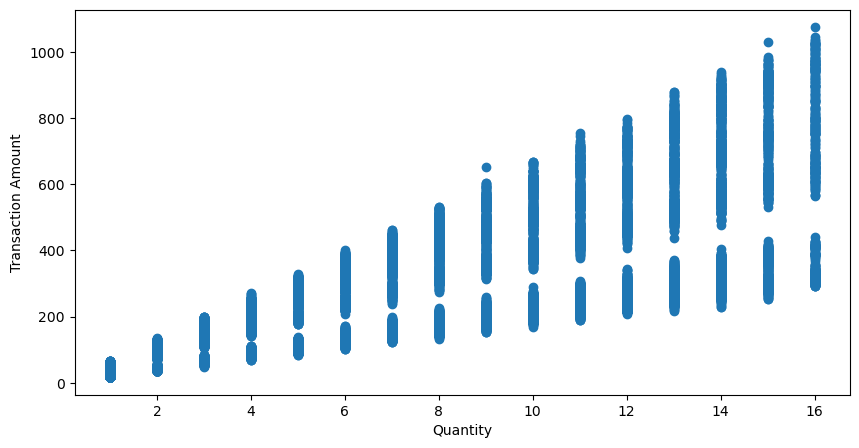

In [14]:

plt.scatter(df['quantity'], df['transaction_amount'])
plt.xlabel("Quantity")
plt.ylabel("Transaction Amount")
plt.show()


## 📦 Transaction Amount Distribution with Outliers

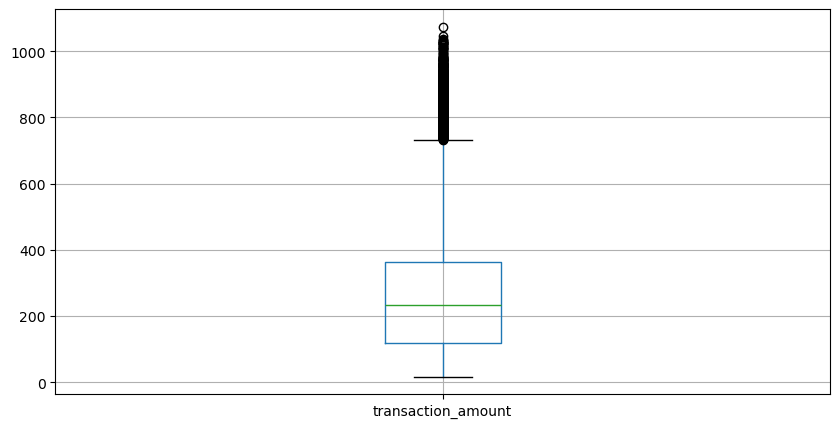

In [15]:

df.boxplot(column='transaction_amount')
plt.show()


## 📉 Transaction Amount Distribution

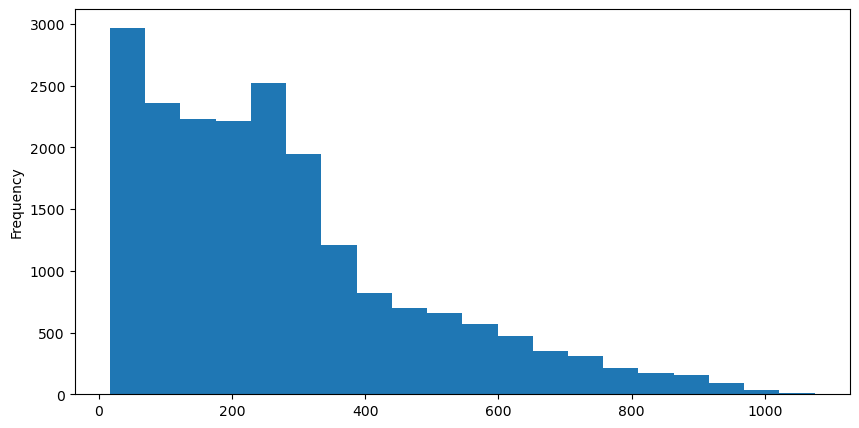

In [16]:

df['transaction_amount'].plot(kind='hist', bins=20)
plt.show()


## 💰 Profit Percentage Distribution

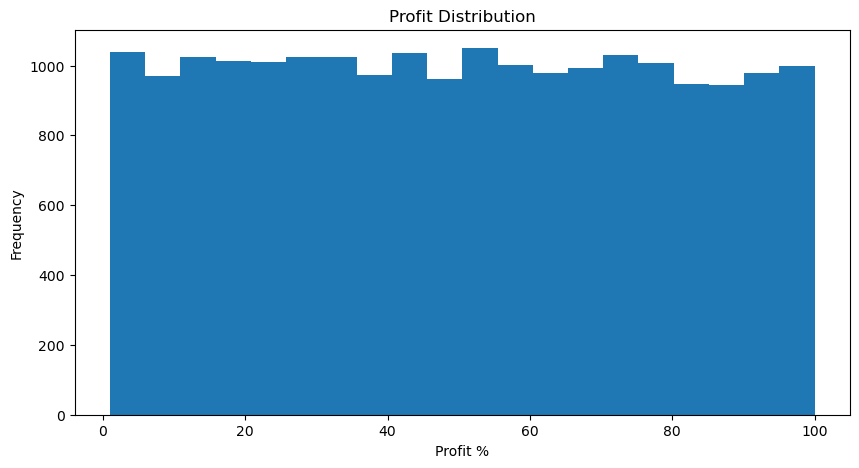

In [17]:

df['profit_percent'].plot(kind='hist', bins=20)
plt.title('Profit Distribution')
plt.xlabel('Profit %')
plt.ylabel('Frequency')
plt.show()



## 📌 Key Business Insights

- Sales show strong variation across different days and hours.
- Evening hours contribute significantly to total revenue.
- Few items dominate overall sales (high-demand products).
- Weekends generally show higher sales compared to weekdays.
- Digital order channels play a major role in transactions.
- Profit margins are well distributed across transactions.

---

## ✅ Conclusion

The dataset is well-structured and suitable for:
- Sales Forecasting
- Customer Segmentation
- Business Optimization

This EDA provides a strong foundation for Machine Learning models.
